In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('airquality_data.csv', encoding='cp1252') 
df

C:\Users\satya\AppData\Local\Temp\ipykernel_24108\1101834110.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('airquality_data.csv', encoding='cp1252')


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
435737,SAMP,24-12-15,West Bengal,ULUBERIA,West Bengal State Pollution Control Board,RIRUO,22.0,50.0,143.0,NaN,"Inside Rampal Industries,ULUBERIA",NaN,2015-12-24
435738,SAMP,29-12-15,West Bengal,ULUBERIA,West Bengal State Pollution Control Board,RIRUO,20.0,46.0,171.0,NaN,"Inside Rampal Industries,ULUBERIA",NaN,2015-12-29
435739,NaN,NaN,andaman-and-nicobar-islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435740,NaN,NaN,Lakshadweep,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df=df.drop_duplicates() 
df

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
435737,SAMP,24-12-15,West Bengal,ULUBERIA,West Bengal State Pollution Control Board,RIRUO,22.0,50.0,143.0,NaN,"Inside Rampal Industries,ULUBERIA",NaN,2015-12-24
435738,SAMP,29-12-15,West Bengal,ULUBERIA,West Bengal State Pollution Control Board,RIRUO,20.0,46.0,171.0,NaN,"Inside Rampal Industries,ULUBERIA",NaN,2015-12-29
435739,NaN,NaN,andaman-and-nicobar-islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435740,NaN,NaN,Lakshadweep,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isna().sum() 

stn_code                       144077
sampling_date                       3
state                               0
location                            3
agency                         149466
type                             5357
so2                             34632
no2                             16222
rspm                            40035
spm                            236908
location_monitoring_station     27303
pm2_5                          425754
date                                7
dtype: int64

In [5]:
percentage_missing=df.isna().sum()*100/len(df) 
percentage_missing.sort_values(ascending=False) 

pm2_5                          97.859185
spm                            54.453097
agency                         34.354630
stn_code                       33.115973
rspm                            9.202010
so2                             7.960135
location_monitoring_station     6.275571
no2                             3.728613
type                            1.231302
date                            0.001609
sampling_date                   0.000690
location                        0.000690
state                           0.000000
dtype: float64

In [6]:
df=df.drop(['stn_code', 'agency','sampling_date','location_monitoring_station','pm2_5'], axis = 1) 
df

,state,location,type,so2,no2,rspm,spm,date
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,1990-02-01
1,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,NaN,NaN,1990-02-01
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,1990-02-01
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,1990-03-01
4,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,NaN,NaN,1990-03-01
...,...,...,...,...,...,...,...,...
435737,West Bengal,ULUBERIA,RIRUO,22.0,50.0,143.0,NaN,2015-12-24
435738,West Bengal,ULUBERIA,RIRUO,20.0,46.0,171.0,NaN,2015-12-29
435739,andaman-and-nicobar-islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435740,Lakshadweep,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns

Index(['state', 'location', 'type', 'so2', 'no2', 'rspm', 'spm', 'date'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 435068 entries, 0 to 435741
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   state     435068 non-null  object 
 1   location  435065 non-null  object 
 2   type      429711 non-null  object 
 3   so2       400436 non-null  float64
 4   no2       418846 non-null  float64
 5   rspm      395033 non-null  float64
 6   spm       198160 non-null  float64
 7   date      435061 non-null  object 
dtypes: float64(4), object(4)
memory usage: 29.9+ MB


In [9]:
ds_objs=['state','location','type','date'] 
ds_num=['so2','no2','rspm','spm'] 


In [10]:
for col in df.columns: 
    if df[col].dtype=='string' or df[col].dtype=='object': 
        df[col]=df[col].fillna(df[col].mode()[0]) 
    else: 
        df[col]=df[col].fillna(df[col].mean()) 

In [11]:
df.isna().sum()

state       0
location    0
type        0
so2         0
no2         0
rspm        0
spm         0
date        0
dtype: int64

In [12]:
subset1=df[['state','type']] 
subset2=df[['state','location']] 

In [13]:
subset1.head()

,state,type
0,Andhra Pradesh,"Residential, Rural and other Areas"
1,Andhra Pradesh,Industrial Area
2,Andhra Pradesh,"Residential, Rural and other Areas"
3,Andhra Pradesh,"Residential, Rural and other Areas"
4,Andhra Pradesh,Industrial Area


In [14]:
subset2.head()

,state,location
0,Andhra Pradesh,Hyderabad
1,Andhra Pradesh,Hyderabad
2,Andhra Pradesh,Hyderabad
3,Andhra Pradesh,Hyderabad
4,Andhra Pradesh,Hyderabad


In [15]:
merged_ds=pd.concat([subset1,subset2],axis=1) 

In [16]:
merged_ds

,state,type,state,location
0,Andhra Pradesh,"Residential, Rural and other Areas",Andhra Pradesh,Hyderabad
1,Andhra Pradesh,Industrial Area,Andhra Pradesh,Hyderabad
2,Andhra Pradesh,"Residential, Rural and other Areas",Andhra Pradesh,Hyderabad
3,Andhra Pradesh,"Residential, Rural and other Areas",Andhra Pradesh,Hyderabad
4,Andhra Pradesh,Industrial Area,Andhra Pradesh,Hyderabad
...,...,...,...,...
435737,West Bengal,RIRUO,West Bengal,ULUBERIA
435738,West Bengal,RIRUO,West Bengal,ULUBERIA
435739,andaman-and-nicobar-islands,"Residential, Rural and other Areas",andaman-and-nicobar-islands,Guwahati
435740,Lakshadweep,"Residential, Rural and other Areas",Lakshadweep,Guwahati


In [17]:
def removeOutlier(column): 
    Q1=column.quantile(0.25) 
    Q2=column.quantile(0.75) 
    IQR=Q2-Q1 
    threshold=1.5*IQR 
    maskCheck=(column<Q1-threshold)|(column>Q2+threshold) 
    return column[~maskCheck]

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 435068 entries, 0 to 435741
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   state     435068 non-null  object 
 1   location  435068 non-null  object 
 2   type      435068 non-null  object 
 3   so2       435068 non-null  float64
 4   no2       435068 non-null  float64
 5   rspm      435068 non-null  float64
 6   spm       435068 non-null  float64
 7   date      435068 non-null  object 
dtypes: float64(4), object(4)
memory usage: 29.9+ MB


In [19]:
cols=['so2','no2','rspm','spm'] 
for col in cols: 
    df[col]=removeOutlier(df[col]) 

In [20]:
df

,state,location,type,so2,no2,rspm,spm,date
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.800000,17.400000,108.871711,220.774796,1990-02-01
1,Andhra Pradesh,Hyderabad,Industrial Area,3.100000,7.000000,108.871711,220.774796,1990-02-01
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.200000,28.500000,108.871711,220.774796,1990-02-01
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.300000,14.700000,108.871711,220.774796,1990-03-01
4,Andhra Pradesh,Hyderabad,Industrial Area,4.700000,7.500000,108.871711,220.774796,1990-03-01
...,...,...,...,...,...,...,...,...
435737,West Bengal,ULUBERIA,RIRUO,22.000000,50.000000,143.000000,220.774796,2015-12-24
435738,West Bengal,ULUBERIA,RIRUO,20.000000,46.000000,171.000000,220.774796,2015-12-29
435739,andaman-and-nicobar-islands,Guwahati,"Residential, Rural and other Areas",10.830468,25.823296,108.871711,220.774796,2015-03-19
435740,Lakshadweep,Guwahati,"Residential, Rural and other Areas",10.830468,25.823296,108.871711,220.774796,2015-03-19


In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
col_label= ['state','location','type']
# Initialize LabelEncoder

encoder = LabelEncoder()
# Iterate over columns
for col in col_label:
        # Fit and transform the column
        df[col] = encoder.fit_transform(df[col])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 435068 entries, 0 to 435741
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   state     435068 non-null  int64  
 1   location  435068 non-null  int64  
 2   type      435068 non-null  int64  
 3   so2       408444 non-null  float64
 4   no2       415756 non-null  float64
 5   rspm      415487 non-null  float64
 6   spm       278168 non-null  float64
 7   date      435068 non-null  object 
dtypes: float64(4), int64(3), object(1)
memory usage: 29.9+ MB


In [24]:
df.describe()

,state,location,type,so2,no2,rspm,spm
count,435068.000000,435068.000000,435068.000000,408444.000000,415756.000000,415487.000000,278168.000000
mean,18.724112,140.181769,4.288693,8.980860,23.177994,98.910375,218.833287
std,10.089083,85.919163,2.221358,5.403565,11.971981,52.434501,9.448833
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,173.866667
25%,12.000000,72.000000,2.000000,5.000000,14.000000,58.000000,220.774796
50%,19.000000,134.000000,5.000000,8.000000,21.800000,94.000000,220.774796
75%,27.000000,207.000000,6.000000,12.000000,30.000000,125.000000,220.774796
max,36.000000,303.000000,9.000000,25.000000,59.000000,249.000000,248.915079


In [25]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract useful time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Drop rows where target or key predictors are missing
model_df = df[['state', 'location', 'type', 'so2', 'no2', 'year', 'month', 'rspm']].dropna() 

In [26]:
X = model_df[['state', 'location', 'type', 'so2', 'no2', 'year', 'month']]
y = model_df['rspm']

In [27]:
df.head()

,state,location,type,so2,no2,rspm,spm,date,year,month
0,0,114,6,4.8,17.4,108.871711,220.774796,1990-02-01,1990,2
1,0,114,1,3.1,7.0,108.871711,220.774796,1990-02-01,1990,2
2,0,114,6,6.2,28.5,108.871711,220.774796,1990-02-01,1990,2
3,0,114,6,6.3,14.7,108.871711,220.774796,1990-03-01,1990,3
4,0,114,1,4.7,7.5,108.871711,220.774796,1990-03-01,1990,3


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) 
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train) 
y_pred = model.predict(X_test) 
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2) 

Model Performance:
MAE : 21.402768321436735
MSE : 964.3175533782203
RMSE: 31.05346282426841
R2 Score: 0.64316707115007


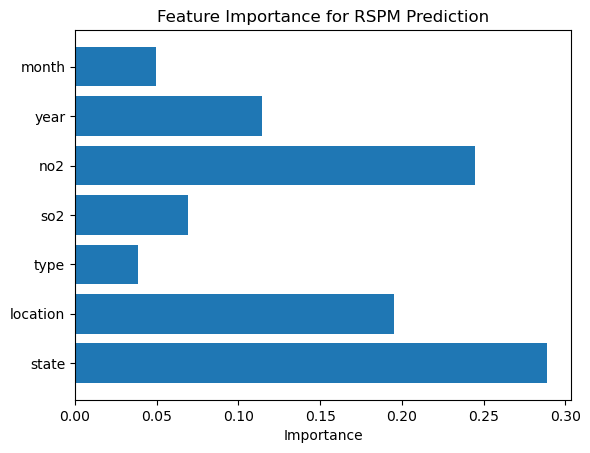

In [29]:
importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance for RSPM Prediction")
plt.show()